# AutoGen: An Introduction to Autogen

This notebook shows some of the advanced use cases of **AutoGen**, such as:
1. **Selection of Agents Dynamically**: Utilizing selector teams to choose the best agent for a specific sub-task.
2. **Handoffs**: Managing transitions between different expert agents.
3. **RAG (Retrieval-Augmented Generation)**: Connecting agents to private vector databases.

To keep things simple in this notebook, we are using **`autogen_agentchat`**, the high-level API built on top of **`autogen-core`**. This provides a more user-friendly interface while still leveraging all the capabilities of AutoGen.

### Workflow Description
In the examples used in this notebook, we are using the **Yahoo Finance API** to fetch data for specified stocks. This data is fed to the agents using specialized tools to generate:
* **Stock Charts**: Visual price trends over a specified period.
* **Financial Reports**: Real-time metrics and strategist debates.

In the second part of the notebook, we manually pull **annual reports (10-K filings)** of a company from their official **SEC filings**. These are cleaned and stored in a **ChromaDB** vector database, allowing the agents to pull high-fidelity evidence using **RAG** tools for deep-dive quantitative analysis.

The 2 cells below import the required libraries and set up the notebook for execution. Please add your API key as required.

In [7]:
%load_ext autoreload
%autoreload 2

import logging
import os
import re

import matplotlib.pyplot as plt
from IPython.display import Image as IPImage
from IPython.display import Markdown, display

# AutoGen Chat Components.
from autogen_agentchat.agents import (
    AssistantAgent,
    CodeExecutorAgent,
    UserProxyAgent,
)
from autogen_agentchat.conditions import TextMentionTermination
from autogen_agentchat.teams import SelectorGroupChat

# AutoGen Extensions.
from autogen_ext.code_executors.local import LocalCommandLineCodeExecutor
from autogen_ext.models.openai import OpenAIChatCompletionClient

import autogen_utils

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

In [ ]:
# Replace "YOUR_OPENAI_API_KEY" with your actual OpenAI API key.
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY"

## Part 1: Dynamic Market Debate & Live Data
**Objective:** Leverage real-time market data to facilitate a debate between opposing investment perspectives.

- **Dynamic Selection:** The `SelectorGroupChat` decides when to call the **Analyst** for data or trigger the **Bull** and **Bear** strategists to debate.
- **Tools:** Integration with `yfinance` via `market_tool` and `plot_tool`.
- **Visualization:** The Analyst generates and displays a technical trend chart directly in the notebook.

In [3]:
async def _run_stock_mission(ticker: str, days: int, task: str, *, model: str = "gpt-4o"):
    model_client = OpenAIChatCompletionClient(model=model)
    # Set up agents.
    analyst = AssistantAgent(
        name="Analyst",
        model_client=model_client,
        tools=[autogen_utils.market_tool, autogen_utils.plot_tool],
        system_message="You ONLY provide raw data and charts. Do NOT interpret or give advice.",
    )
    bull = AssistantAgent(
        name="Bull_Strategist",
        model_client=model_client,
        tools=[autogen_utils.financial_tool],
        system_message="You ONLY look for positives. Speak briefly and wait for the Bear to counter.",
    )
    bear = AssistantAgent(
        name="Bear_Strategist",
        model_client=model_client,
        tools=[autogen_utils.financial_tool],
        system_message="You ONLY look for risks. Speak briefly and challenge the Bull.",
    )
    executive = UserProxyAgent(name="Executive")
    # Set up the selector team.
    team = SelectorGroupChat(
        [analyst, bull, bear, executive],
        model_client=model_client,
        termination_condition=TextMentionTermination("TERMINATE"),
    )
    print(f"\nDYNAMIC DEBATE: {ticker.upper()}")
    print("=" * 45)
    # Stream messages.
    history = []
    async for message in team.run_stream(task=task):
        history.append(message)
        msg_type = str(type(message)).lower()
        if "toolcall" in msg_type or "tool_response" in msg_type:
            continue
        source = message.source.upper()
        if hasattr(message, "content"):
            content_str = str(message.content)
            # Render image.
            # Check for "autogen_core" or the markdown attachment syntax.
            if "autogen_core" in content_str or "attachment://" in content_str:
                if source == "ANALYST":
                    print(f"\n[{source}]: Rendering market trend chart...")
                    # Use the ticker-based filename the utility saves.
                    chart_filename = f"{ticker_in.upper()}_chart.png"
                    if os.path.exists(chart_filename):
                        display(IPImage(filename=chart_filename))
                    else:
                        print(f"Chart file {chart_filename} not found yet.")
                continue
            # Render text.
            text = content_str.strip()
            if text and not text.startswith("ToolResponse"):
                print(f"\n[{source}]: {text}")
        if "TERMINATE" in str(message.content).upper():
            break
    return history

### User Input and Mission
The cell below:
- Collects ticker and days for analysis.
- Lets user pick mission type: standard, bear-case, or peer comparison.
- Maps choice to a task and runs `run_stock_mission`.

Ticker:  TSLA
Days:  360



--- Mission Options ---
1. Standard Debate (Press Enter)
2. Focus only on the Bear case
3. Compare this stock to industry peers


Select 1, 2, or 3:  1



 DYNAMIC DEBATE: TSLA

[USER]: Analyst: Provide data for TSLA (360 days). Bull and Bear: Debate the value.


Enter your response:  Show me the stock chart of the company



[EXECUTIVE]: Show me the stock chart of the company

[ANALYST]: 📊 Rendering market trend chart...


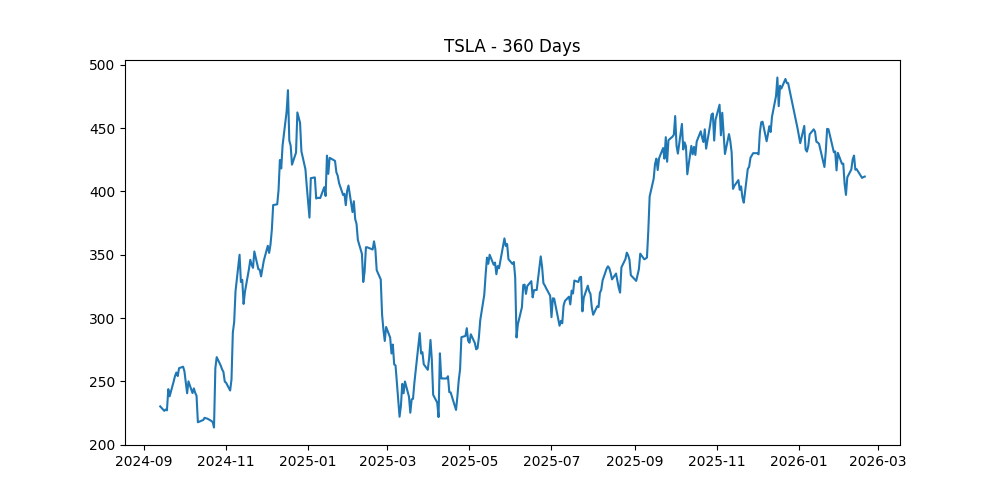

Enter your response:  Give me all the financial numbers of company in a neat table format. Ensure details such as P/E ratio etc are fetched. 



[EXECUTIVE]: Give me all the financial numbers of company in a neat table format. Ensure details such as P/E ratio etc are fetched.

[ANALYST]: ```
| Financial Metric                | Value          |
|---------------------------------|----------------|
| Price/Earnings (Trailing)       | 384.5794       |
| Forward P/E                     | 146.73788      |
| Profit Margin                   | 0.040009998    |
| Revenue Growth (YoY)            | -0.031         |
| Debt to Equity                  | 17.763         |
```

[BULL_STRATEGIST]: TSLA's financials show great potential with impressive P/E ratios indicating high investor confidence. The company has managed debt efficiently and maintained profitability. 

Now, Bear, your counterpoints?

[BEAR_STRATEGIST]: Certainly, the high P/E ratio is worth a deeper examination. It suggests that the stock might be overvalued, reflecting excessive investor optimism rather than fundamental financial strength. A decline in revenue growth (YoY) by 

Enter your response:  Now that both of you have stated your perspectives, can you tell me if I should buy or sell the stock? 



[EXECUTIVE]: Now that both of you have stated your perspectives, can you tell me if I should buy or sell the stock?

[BULL_STRATEGIST]: TSLA's strong investor confidence, innovative edge in the EV market, and resilient profit margins despite industry challenges suggest a promising buy for potential long-term gains. Please consider market conditions and your risk tolerance.

[BEAR_STRATEGIST]: Caution is advised. The high P/E ratio and negative revenue growth point to potential overvaluation and operational challenges. The elevated debt-to-equity ratio also raises stability concerns. Consider these risks carefully before deciding.


Enter your response:  terminate



[EXECUTIVE]: terminate
Enter your response: 

In [5]:
# Set user inputs.
ticker_in = input("Ticker: ").upper().strip()
days_in = int(input("Days: "))
print("\n--- Mission Options ---")
print("1. Standard Debate (Press Enter)")
print("2. Focus only on the Bear case")
print("3. Compare this stock to industry peers")
user_choice = input("Select 1, 2, or 3: ").strip()
# Map numbers to task instructions.
tasks = {
    "1": f"Analyst: Provide data for {ticker_in} ({days_in} days). Bull and Bear: Debate the value.",
    "2": f"Analyst: Provide data. Bear_Strategist: Give a deep dive on every risk you find.",
    "3": f"Analyst: Provide data. Bull and Bear: Debate how {ticker_in} stacks up against its main competitors.",
}
# Default task if the user enters an invalid option.
final_task = tasks.get(user_choice, f"Debate {ticker_in} based on {days_in} days of data.")
# Execute the mission.
history = await _run_stock_mission(ticker=ticker_in, days=days_in, task=final_task)

## Part 2: SEC Filings & Quantitative RAG
**Objective:** Perform a deep-dive analysis into official company filings using Retrieval-Augmented Generation.

- **Data Pipeline:** A manual process to fetch 10-K filings from SEC EDGAR, clean HTML/PDF noise, and embed chunks into **ChromaDB**.
- **Agentic RAG:** The **Senior Quant Analyst** queries the vector database to find specific geographic revenue splits and risk factors.
- **Code Execution:** The **Quant Runtime** agent writes and executes Python code locally to transform raw 10-K tables into formatted visualizations.

The cell below retrieves the SEC annual reports for the user-specified stocks and embeds them into the Chroma database.

In [6]:
# Get the ticker from the user.
ticker_in = input("Enter the stock ticker: ").strip().upper()
if ticker_in:
    print(f"Starting process for {ticker_in}...")
    # Fetch and clean the 10-K filing.
    clean_path = autogen_utils.fetch_and_clean_10k(ticker_in)
    if "Error" not in clean_path:
        # Embed the 10-K into ChromaDB.
        collection_id = autogen_utils.embed_10k_to_chroma(ticker_in, clean_path)
        print(f"Ready for RAG! Collection ID: {collection_id}")
    else:
        print(f"{clean_path}")

Enter the stock ticker:  TSLA


Starting process for TSLA...
 Encoding 282 chunks for TSLA...


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|███████████████████████████████████████████████████████████████████████████████████████| 79.3M/79.3M [00:01<00:00, 67.4MiB/s]


Ready for RAG! Collection ID: tsla_10k


The cell below defines an asynchronous function `run_beautified_mission` that generates a comprehensive financial brief for a given stock ticker. It orchestrates a team of agents to:

1. **Revenue Breakdown** - Extract revenue data from the 10-K by geography, or fallback to product/segment revenue if geographic data is missing.
2. **Pie Chart** - Automatically generate a pie chart of the revenue breakdown using actual dollar figures and save it as `analysis_output.png`.
3. **Financial Ratios** - Retrieve key metrics like Trailing P/E, Forward P/E, Profit Margin, Revenue Growth (YoY), and Debt-to-Equity, and display them as a clean Markdown table.
4. **Top 3 Risks** - Identify the top three material risks from the 10-K.
5. **In-Depth Analysis** - Summarize the company's financials and suggest a buy/sell recommendation.

It then streams outputs from the agents: displaying clean Markdown for the Analyst's results, confirming chart creation or showing errors from the Runtime agent, and finally printing a mission completion message when the `TERMINATE` keyword is reached.

In [8]:
async def _run_beautified_mission(ticker_symbol: str):
    task = (
        f"Generate a financial brief for {ticker_symbol}.\n\n"
        f"STEP 1 - REVENUE BREAKDOWN:\n"
        f"Search the 10-K for revenue broken down by geography (country/region). "
        f"If no geographic breakdown exists, fall back to revenue by product line "
        f"or business segment. Use whatever revenue table IS available -- do not "
        f"leave this section empty.\n\n"
        f"STEP 2 - PIE CHART:\n"
        f"Write Python code to visualize the revenue breakdown from Step 1 as a "
        f"pie chart. Use ONLY actual revenue dollar figures -- not ratios or percentages. "
        f"Save as 'analysis_output.png'.\n\n"
        f"STEP 3 - FINANCIAL RATIOS:\n"
        f"Use the financial tool to retrieve: Trailing P/E, Forward P/E, "
        f"Profit Margin, Revenue Growth (YoY), and Debt to Equity. "
        f"Display as a clean Markdown table.\n\n"
        f"STEP 4 - TOP 3 RISKS:\n"
        f"Search the 10-K for the top 3 material risks facing the company.\n"
        f"STEP 5 - Give an in-depth analysis of the financials of the company and suggest if it is a buy or a sell for the stock.\n"
        f"Search the 10-K for all the information necessary.\n"
    )
    print(f"Mission started for {ticker_symbol}...\n")
    async for message in team.run_stream(task=task):
        if hasattr(message, "source"):
            # Handle analyst output.
            if message.source == "Analyst" and isinstance(message.content, str):
                content = message.content
                # Block raw tool bleed-through.
                if any(skip in content for skip in [
                    "Evidence from",
                    "### Evidence",
                    "Financials for",
                    "exitcode:",
                ]):
                    continue
                display_text = autogen_utils.clean_markdown(content)
                if display_text:
                    display(Markdown(display_text))
            # Handle runtime output.
            if message.source == "Quant_Runtime":
                content_str = str(message.content)
                if "exitcode: 0" in content_str:
                    print("[System]: Chart generated successfully.\n")
                elif "exitcode: 1" in content_str:
                    print("[System]: Code execution failed:")
                    # Extract just the error, not the whole blob.
                    error_match = re.search(
                        r'(Traceback.*?)(?=\n\n|\Z)', content_str, re.DOTALL
                    )
                    if error_match:
                        print(error_match.group(1))
                    else:
                        print(content_str)
        elif hasattr(message, "stop_reason"):
            print(f"Mission complete: {message.stop_reason}\n")

The cell below sets up the quant analysis environment:

- Initializes `gpt-4o` chat client and a local code executor (`quant_sandbox`).
- Defines the **Analyst agent** to fetch 10-K data via RAG and financial tools, produce clean Markdown tables, and generate pie charts of actual revenue figures.
- Defines the **Runtime agent** to execute Python code.
- Configures a **team** of Analyst + Runtime with termination on `TERMINATE`.
- Prompts for a stock ticker and starts `run_beautified_mission`, streaming results and charts.

In [9]:
model_client = OpenAIChatCompletionClient(model="gpt-4o")
os.makedirs("quant_sandbox", exist_ok=True)
local_executor = LocalCommandLineCodeExecutor(work_dir="quant_sandbox")
# Define the agents.
analyst = AssistantAgent(
    name="Analyst",
    model_client=model_client,
    tools=[autogen_utils.rag_search_tool, autogen_utils.financial_tool],
    system_message="""You are a Senior Quantitative Analyst and Data Architect.

    CRITICAL DATA RETRIEVAL RULES:
    1. First, search for GEOGRAPHIC revenue splits by country or region
       (United States, China, Europe, etc.).
    2. If geographic splits are NOT available, fall back to the next best option:
       - Revenue by PRODUCT LINE or BUSINESS SEGMENT (e.g., Automotive, Energy).
       - Clearly label which type of breakdown you are showing.
    3. NEVER make up numbers. If data is unavailable, say so and use what IS available.
    4. Do NOT use financial ratios (P/E, Profit Margin, etc.) in a pie chart --
       these are not revenue figures and make no sense visually.

    STRICT FORMATTING RULES:
    1. Every Markdown table MUST have:
       - A blank line BEFORE the table
       - A blank line AFTER the table
       - Proper pipe and dash formatting:

         | Column A | Column B |
         |----------|----------|
         | Value 1  | Value 2  |

    2. NEVER write a table on a single line or without separator rows.
    3. Convert ALL raw JSON from financial_tool into a Markdown table.
    4. Use '##' for section headers.
    5. Never leak raw tool output or evidence fragments into your response.

    VISUALIZATION:
    - Use actual revenue figures (geographic or segment) for the pie chart.
    - NEVER use financial ratios as pie chart data.
    - NEVER call plt.show() in your code. Only call plt.savefig('analysis_output.png').
    - Save as 'analysis_output.png'.

    Always end your response with 'TERMINATE'.""",
)
quant_runtime = CodeExecutorAgent(
    name="Quant_Runtime",
    code_executor=local_executor,
)
# Configure the team.
termination = TextMentionTermination("TERMINATE")
team = SelectorGroupChat(
    [analyst, quant_runtime],
    model_client=model_client,
    termination_condition=termination,
)
# Run the mission.
user_ticker = input("Enter Ticker for Quant Analysis: ").strip().upper()
if user_ticker:
    print(f"Starting quant mission for {user_ticker}...")
    await _run_beautified_mission(user_ticker)

/tmp/ipykernel_2968/1687277239.py:3: UserWarning: Using LocalCommandLineCodeExecutor may execute code on the local machine which can be unsafe. For security, it is recommended to use DockerCommandLineCodeExecutor instead. To install Docker, visit: https://docs.docker.com/get-docker/
  local_executor = LocalCommandLineCodeExecutor(work_dir="quant_sandbox")
/tmp/ipykernel_2968/1687277239.py:46: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  quant_runtime = CodeExecutorAgent(


Enter Ticker for Quant Analysis:  TSLA


 Starting Quant Mission for TSLA...
 Mission Started for TSLA...



### Step 1: Revenue Breakdown by Product Line

Based on the data from the 10-K report, Tesla's revenue breakdown for the year ended December 31, 2023, is as follows:

| Revenue Source                       | Revenue ($ in millions) |
|--------------------------------------|-------------------------|
| Automotive Sales                     | 78,509                  |
| Automotive Regulatory Credits        | 1,790                   |
| Energy Generation and Storage Sales  | 5,515                   |
| Services and Other                   | 8,319                   |
| Automotive Leasing                   | 2,120                   |
| Energy Generation and Storage Leasing| 520                     |
| **Total Revenues**                   | 96,773                  |

### Step 2: Pie Chart

Here is the Python code to visualize the revenue breakdown as a pie chart.

```python
import matplotlib.pyplot as plt

# Revenue data
labels = [
    "Automotive Sales",
    "Automotive Regulatory Credits",
    "Energy Generation and Storage Sales",
    "Services and Other",
    "Automotive Leasing",
    "Energy Generation and Storage Leasing"
]
sizes = [78509, 1790, 5515, 8319, 2120, 520]

# Plot
plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Save image
plt.savefig('analysis_output.png')
```

### Step 3: Financial Ratios

I will now retrieve the financial ratios.

### Step 3: Financial Ratios

Here are the retrieved financial ratios for Tesla:

| Metric                     | Value      |
|----------------------------|------------|
| Trailing P/E               | 383.40     |
| Forward P/E                | 146.29     |
| Profit Margin              | 4.00%      |
| Revenue Growth (YoY)       | -3.10%     |
| Debt to Equity             | 17.76      |

### Step 4: Top 3 Risks

Let's search the 10-K for the top 3 material risks facing Tesla.

### Step 4: Top 3 Risks

The top three material risks facing Tesla as mentioned in the 10-K report are:

1. **Cybersecurity Threats**
   - Cybersecurity risks include operational risks, intellectual property theft, fraud, extortion, harm to employees or customers, and violation of data privacy or security laws.
   - Cybersecurity risk management involves proactive reviews, internal audits, third-party assessments, and a bug bounty program.

2. **Component Supply Chain Risks**
   - Delays or disruptions in obtaining components from suppliers may impact production schedules and cost-effectiveness.
   - Factors like trade policies, natural disasters, labor issues, and supplier insolvency can exacerbate these risks.

3. **Production and Operational Risks**
   - Ramping up production of current products and development of future products could encounter complications that affect brand, financial condition, and operating results.
   - Efficient management of suppliers and resources is crucial for maintaining production continuity.

### Step 5: In-depth Financial Analysis and Stock Recommendation

To provide an in-depth analysis, the following factors from the 10-K and financials should be considered:

- **Revenue and Profitability**: Tesla's revenue shows a minor decline Year-over-Year. The company's profitability, with a 4% profit margin, reflects operative efficiencies but is on the lower side compared to industry averages.
- **Valuation**: The P/E ratios (both trailing and forward) are relatively high, which may suggest an overvaluation or expectations of significant future growth by the market.
- **Debt Management**: Tesla maintains a low debt-equity ratio, which indicates a conservative approach to leveraging.
- **Market Risks**: The stock is exposed to considerable market risks from fluctuating raw material prices, global trade policies, and technology cycles.

Given these factors, a conservative investment strategy might suggest caution due to high valuation levels and moderate growth prospects. However, long-term investors believing in Tesla’s innovation capacity and market expansion plans may consider it a "Hold".

The recommendation would be to analyze personal risk tolerance. If risk-averse, consider taking profits or holding your position; if risk-tolerant, maintain your investment for potential long-term gains.

**Recommendation**: Hold

 Mission Complete: Text 'TERMINATE' mentioned



### Generated Code Output
- The results produced by the code above are displayed below.

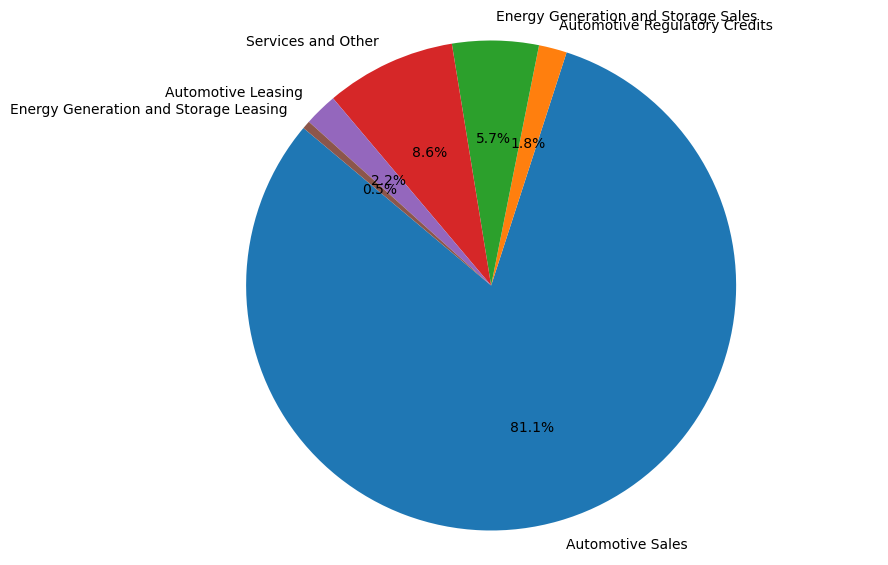

In [10]:
# Revenue data.
labels = [
    "Automotive Sales",
    "Automotive Regulatory Credits",
    "Energy Generation and Storage Sales",
    "Services and Other",
    "Automotive Leasing",
    "Energy Generation and Storage Leasing",
]
sizes = [78509, 1790, 5515, 8319, 2120, 520]
# Create the plot.
plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140)
# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis("equal")
# Save the image.
plt.savefig("analysis_output.png")